# 01 — Data Acquisition

**What we do:** load the raw earthquake catalogue downloaded from the USGS
Earthquake Catalog API for Japan and describe the data source and its columns.

**Why:** the whole project models seismic activity, so we first need a clean,
documented record of *where* and *when* earthquakes happened. This notebook
establishes provenance (where the data comes from), shows the variables we have,
and produces a first geographic picture of the raw events. It maps directly to
*Criterion 1 — Problem Formulation: Data Source / Description.*

## The phenomenon and use case
We model the **annual number of magnitude >= 4.0 earthquakes per spatial grid
cell** over Japan. Such intensity maps are used for **seismic hazard
assessment**, insurance/re-insurance pricing, infrastructure planning and
prioritising monitoring. A Bayesian treatment gives not just a point estimate
of activity per region but a full *uncertainty* around it — essential when some
cells have very few observations.

## Data source — USGS Earthquake Catalog
- **Provider:** U.S. Geological Survey (USGS), FDSN `event` web service.
- **Endpoint:** `https://earthquake.usgs.gov/fdsnws/event/1/query` (CSV, no
  registration required).
- **Query used:** bounding box for Japan `lat 24-50 N`, `lon 122-154 E`,
  `minmagnitude = 4.0`, period `2000-2023`.
- **Download strategy:** the API returns at most 20 000 records per request, so
  `utils/download_data.py` downloads **year by year** (24 requests) with a
  1-second pause between calls and concatenates the results.

### Columns of interest
| column | meaning |
|--------|---------|
| `time` | event origin time (UTC, ISO-8601) |
| `latitude`, `longitude` | epicentre coordinates (degrees) |
| `depth` | hypocentre depth (km) |
| `mag`, `magType` | magnitude and its scale (mostly `mb`/`mww`) |
| `place` | human-readable location |
| `id`, `net` | catalogue identifiers |
| `*Error`, `nst`, `gap`, `rms`, `dmin` | measurement-quality metadata |

In [1]:
import sys, os, warnings
sys.path.append("..")            # make the utils package importable
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110

from utils.display import display_df, display_image

In [2]:
RAW_PATH = "../data/raw/earthquakes_japan.csv"
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (33106, 22)
Columns: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2000-12-30T19:42:52.710Z,24.317,122.974,55.6,5.1,mb,96.0,NaN,NaN,1.00,...,2014-11-07T01:11:47.523Z,"16 km S of Yonakuni, Japan",earthquake,NaN,NaN,NaN,37.0,reviewed,us,us
1,2000-12-28T07:54:47.320Z,43.175,147.770,68.4,4.4,mb,26.0,NaN,NaN,1.28,...,2014-11-07T01:11:46.935Z,"109 km SE of Shikotan, Russia",earthquake,NaN,15.8,NaN,7.0,reviewed,us,us
2,2000-12-28T05:24:53.430Z,34.200,139.108,33.0,4.6,mb,18.0,NaN,NaN,1.19,...,2014-11-07T01:11:46.925Z,"near the south coast of Honshu, Japan",earthquake,NaN,NaN,NaN,1.0,reviewed,us,us
3,2000-12-28T04:25:12.150Z,34.045,139.160,33.0,4.0,mb,11.0,NaN,NaN,1.00,...,2014-11-07T01:11:46.898Z,"72 km SSE of Shimoda, Japan",earthquake,NaN,NaN,NaN,2.0,reviewed,us,us
4,2000-12-26T22:12:47.090Z,44.557,148.173,33.0,4.8,mb,76.0,NaN,NaN,0.88,...,2014-11-07T01:11:46.729Z,"78 km SSE of Kuril’sk, Russia",earthquake,NaN,NaN,NaN,37.0,reviewed,us,us


### Basic statistics
We confirm the data covers the intended region, magnitude floor and time span,
and check for missing values in the variables we will actually use.

In [3]:
df["year"] = df["time"].str[:4].astype(int)

print("Time span      :", df["year"].min(), "->", df["year"].max())
print("Magnitude range:", df["mag"].min(), "->", df["mag"].max())
print("Latitude range :", round(df["latitude"].min(),2), "->", round(df["latitude"].max(),2))
print("Longitude range:", round(df["longitude"].min(),2), "->", round(df["longitude"].max(),2))
print("\nMissing values in key columns:")
print(df[["latitude","longitude","mag","time"]].isnull().sum())

display_df(df[["depth","mag","horizontalError","depthError"]].describe(),
           caption="Numeric summary of selected columns")

Time span      : 2000 -> 2023
Magnitude range: 4.0 -> 9.1
Latitude range : 24.0 -> 49.97
Longitude range: 122.0 -> 154.0

Missing values in key columns:
latitude     0
longitude    0
mag          0
time         0
dtype: int64


,depth,mag,horizontalError,depthError
count,33106.000000,33106.000000,11610.000000,23551.000000
mean,67.159249,4.537732,7.671724,7.942731
std,99.700616,0.400739,2.548304,6.599776
min,0.000000,4.000000,1.300000,0.000000
25%,12.340000,4.300000,6.000000,4.100000
50%,35.000000,4.500000,7.400000,6.600000
75%,60.877500,4.700000,9.100000,9.600000
max,686.390000,9.100000,23.800000,72.700000


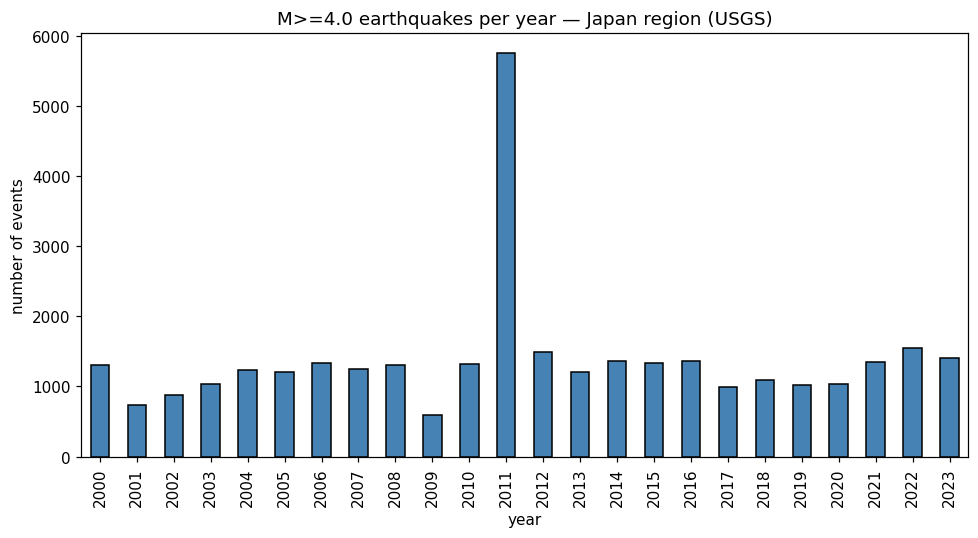

2011 events: 5746 vs median year: 1275


In [4]:
# Events per year — note the huge spike in 2011 (Tohoku M9.0 + aftershocks).
per_year = df.groupby("year").size()
ax = per_year.plot(kind="bar", color="steelblue", edgecolor="k")
ax.set_title("M>=4.0 earthquakes per year — Japan region (USGS)")
ax.set_xlabel("year"); ax.set_ylabel("number of events")
plt.tight_layout(); plt.show()
print("2011 events:", int(per_year.loc[2011]),
      "vs median year:", int(per_year.median()))

### Map of raw events
A scatter of every epicentre, coloured by magnitude. This is our first look at
the **spatial structure** the models must capture: activity is concentrated
along the Pacific subduction zones on the **east coast** and the Nankai trough
to the south, and is far sparser inland and to the west.

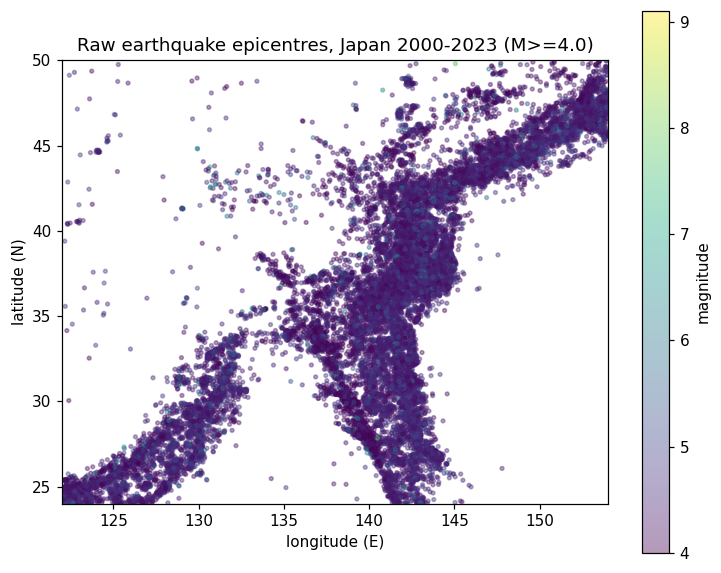

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(df["longitude"], df["latitude"], c=df["mag"],
                cmap="viridis", s=6, alpha=0.4)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8); cbar.set_label("magnitude")
ax.set_xlim(122, 154); ax.set_ylim(24, 50)
ax.set_xlabel("longitude (E)"); ax.set_ylabel("latitude (N)")
ax.set_title("Raw earthquake epicentres, Japan 2000-2023 (M>=4.0)")
ax.set_aspect("equal")
os.makedirs("../report/figures", exist_ok=True)
fig.savefig("../report/figures/01_raw_map.png", bbox_inches="tight", dpi=120)
plt.show()

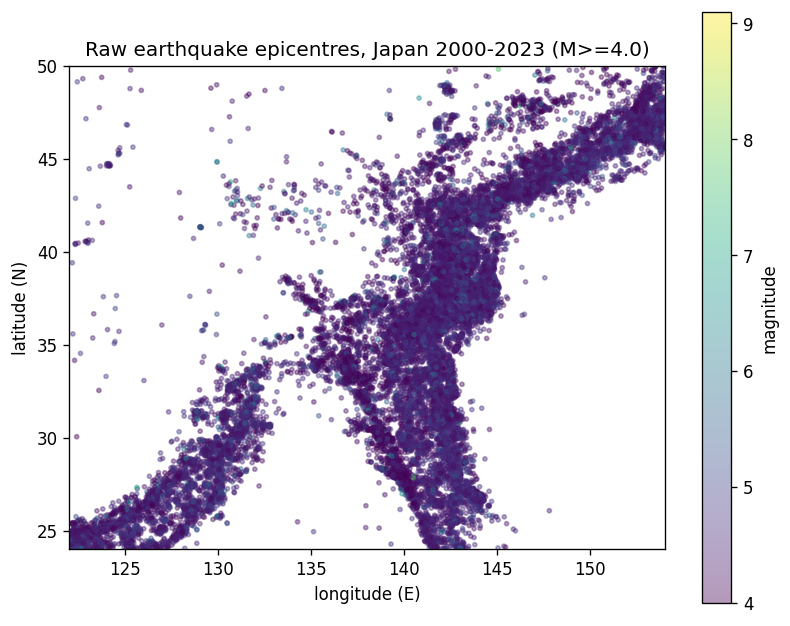

In [6]:
# Demonstrating the display_image helper on the figure we just saved.
display_image("../report/figures/01_raw_map.png", width=520)

## Summary
- We loaded **~33 000 events** spanning 2000-2023, magnitude 4.0-9.1, all within the
  Japan bounding box and with **no missing coordinates / magnitudes**.
- The **2011 spike** (Tohoku M9.0 and its aftershock sequence) is already
  visible and will reappear as an *outlier* in the posterior-predictive and
  model-comparison notebooks.
- Activity is strongly **spatially structured** (east >> west), which motivates
  comparing a spatially-naive model with a hierarchical one.

Next: `02_preprocessing.ipynb` aggregates these point events into a 2x2 degree
grid of annual counts — the input to the Bayesian models.